<a href="https://colab.research.google.com/github/nriley09/COMP3800-Project-1-Submission/blob/main/NRileyProject_1Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#Loads python libraries into the file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Mounts google drive to the file
from google.colab import drive
drive.mount('/content/drive')

#Import Database
df = pd.read_csv('/content/drive/MyDrive/electricvehicles.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Github link: https://github.com/nriley09/COMP3800-Project-1-Submission

Step 1:

The data source is the Electric Vehicle Population Data in the State of Washington. I found the source on Data.gov and it was provided by the Washington State Department of Licensing. The dataset includes information about each electric vehicle in Washington State including its VIN, County, City, State, Postal Code, Model, Make, Model Year, Electric Vehicle Type, CAFV Eligibility, Electric Range, Legislative District, DOL Vehicle ID, Vehicle Location, Electric Utility, and 2020 GEOID.

Link: https://catalog.data.gov/dataset/electric-vehicle-population-data?from_hint=eyJzb3J0IjoicG9wdWxhcml0eSJ9

Main Inquiry Question:
* What types of electric vehicles are the most popular in Washington State?

Sub Questions:
* Which vehicle makes and models are the most common in Washington State?
* How does electric range vary across make?
* What Battery Type is the most prevalent in Washington State?


Step 2 - Data Cleaning:

A.) Drop unwanted features if necessary

In [26]:
#Drop Unwanted Data Columns
ev_df = df.drop(columns=[
    'VIN (1-10)',
    'County',
    'City',
    'Model Year',
    'Postal Code',
    'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
    'Legislative District',
    'Vehicle Location',
    'Electric Utility',
    '2020 GEOID'
    ])

#Displays the remaining columns
ev_df.head()

,State,Make,Model,Electric Vehicle Type,Electric Range,DOL Vehicle ID
0,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),266.0,102765120
1,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),220.0,326796641
2,WA,TESLA,MODEL S,Battery Electric Vehicle (BEV),208.0,166294418
3,WA,HYUNDAI,KONA,Battery Electric Vehicle (BEV),258.0,127090015
4,WA,TESLA,MODEL 3,Battery Electric Vehicle (BEV),220.0,272512824


B.) Check for missing values and address them

In [27]:
#Sum of missing values in each column
print('Missing Values Before')
print(ev_df.isnull().sum())

#Percentage of missing values in each column
print('\nMissing Values Percentage')
for cols in ev_df.columns:
  pct_missing = (ev_df[cols].isnull().sum())/ev_df.shape[0]
  print(cols, pct_missing)

Missing Values Before
State                     0
Make                      0
Model                     0
Electric Vehicle Type     0
Electric Range           13
DOL Vehicle ID            0
dtype: int64

Missing Values Percentage
State 0.0
Make 0.0
Model 0.0
Electric Vehicle Type 0.0
Electric Range 4.418867886047595e-05
DOL Vehicle ID 0.0


In [28]:
#Address missing values
ev_df = ev_df.dropna(subset='Electric Range')

#Checks for missing values in each column
print('\nMissing Values After')
print(ev_df.isnull().sum())

#Percentage of missing values in each column
print('\nMissing Values Percentage')
for cols in ev_df.columns:
  pct_missing = (ev_df[cols].isnull().sum())/ev_df.shape[0]
  print(cols, pct_missing)


Missing Values After
State                    0
Make                     0
Model                    0
Electric Vehicle Type    0
Electric Range           0
DOL Vehicle ID           0
dtype: int64

Missing Values Percentage
State 0.0
Make 0.0
Model 0.0
Electric Vehicle Type 0.0
Electric Range 0.0
DOL Vehicle ID 0.0


C.) Check if there are any duplicate values and address them


*  I used the DOL Vehicle ID column as the same value would refer to the same vehicle.



In [29]:
#Determines number of duplicate vehicles
duplicated_vehicles = ev_df.duplicated(subset='DOL Vehicle ID').sum()
print('Number of Duplicate Vehicles: ', duplicated_vehicles)

#Shape before deduplication
print('\nShape Before Deduplication: ', ev_df.shape)

Number of Duplicate Vehicles:  0

Shape Before Deduplication:  (294180, 6)


D.) Check the data type of each column and correct any errors
*   The data types are correct for my research.


In [30]:
#Prints column data types before correction
print(ev_df.dtypes)

State                     object
Make                      object
Model                     object
Electric Vehicle Type     object
Electric Range           float64
DOL Vehicle ID             int64
dtype: object


E.) Check and address any inconsistent inputs for categorical variables
 * I removed rows that were not in the state of Washington because my main inquiry question focuses on the state of Washington.
 * The values in the make, state, and electric vehicle type column are consistent.


In [31]:
#Remove leading and trailing spaces for categorical variables
ev_df['State'] = ev_df['State'].str.strip()
ev_df['Make'] = ev_df['Make'].str.strip()
ev_df['Electric Vehicle Type'] = ev_df['Electric Vehicle Type'].str.strip()

In [32]:
#Checks values in the state column
print(ev_df['State'].value_counts())

State
WA    293420
CA       176
VA        97
MD        47
FL        45
TX        44
NV        26
OR        25
CO        25
NC        22
AZ        22
IL        18
GA        17
NY        13
MO        12
NJ        11
DC        10
ID        10
MI         9
AL         9
MA         8
TN         8
PA         7
SC         7
NE         7
RI         6
CT         6
OH         6
KY         5
KS         5
BC         5
LA         5
NM         5
NH         4
WI         4
IN         3
UT         3
HI         3
MN         3
AE         3
WY         2
SD         2
AR         2
OK         2
AK         2
IA         2
ME         2
QC         1
GU         1
MT         1
DE         1
MS         1
Name: count, dtype: int64


In [33]:
#Drops rows that do not include WA as the state
ev_df = ev_df[ev_df['State'] == 'WA']

#Checks values in the state column after removing rows
print(ev_df['State'].value_counts())

State
WA    293420
Name: count, dtype: int64


In [34]:
#Checks values in the make column
print(ev_df['Make'].unique())
print(ev_df['Make'].value_counts())

['TESLA' 'HYUNDAI' 'NISSAN' 'FIAT' 'KIA' 'MITSUBISHI' 'CHEVROLET' 'BMW'
 'AUDI' 'JEEP' 'VOLVO' 'LEXUS' 'JAGUAR' 'TOYOTA' 'FORD' 'GENESIS' 'RIVIAN'
 'LINCOLN' 'MAZDA' 'DODGE' 'SUBARU' 'CHRYSLER' 'SMART' 'PORSCHE' 'HONDA'
 'MERCEDES-BENZ' 'VOLKSWAGEN' 'MINI' 'GMC' 'CADILLAC' 'LUCID' 'POLESTAR'
 'BRIGHTDROP' 'FISKER' 'ACURA' 'LAND ROVER' 'ALFA ROMEO' 'LAMBORGHINI'
 'VINFAST' 'RAM' 'TH!NK' 'MULLEN AUTOMOTIVE INC.' 'BENTLEY' 'ROLLS-ROYCE'
 'WHEEGO ELECTRIC CARS' 'ASTON MARTIN' 'FERRARI' 'AZURE DYNAMICS'
 'MASERATI']
Make
TESLA                     120514
CHEVROLET                  19927
FORD                       15946
NISSAN                     15921
KIA                        14564
TOYOTA                     13488
BMW                        12122
HYUNDAI                    11945
RIVIAN                      9518
VOLVO                       7914
VOLKSWAGEN                  7877
AUDI                        6089
JEEP                        6042
CHRYSLER                    3555
MERCEDES-BENZ   

In [35]:
#Checks values in the model column
print(ev_df['Model'].unique())
print(ev_df['Model'].value_counts())

['MODEL 3' 'MODEL S' 'KONA' 'LEAF' '500' 'MODEL Y' 'NIRO' 'OUTLANDER'
 'MODEL X' 'BOLT EV' 'X5' 'E-TRON' 'VOLT' 'WRANGLER' 'Q6' 'XC90' '745E'
 'RX' 'I-PACE' 'EV6' 'NX' 'A3' 'PRIUS' 'F-150' 'I3' 'C-MAX' 'GV60' 'XC60'
 'RZ' 'R1S' 'TUCSON' 'FUSION' 'AVIATOR' 'CX-90' 'R1T' 'GRAND CHEROKEE'
 'HORNET' 'SOLTERRA' 'Q5 E' 'I5' 'BZ4X' '530E' 'Q5' 'PACIFICA' 'SPORTAGE'
 'EQ FORTWO' 'CAYENNE' 'I4' 'PRIUS PRIME (PHEV)' 'CLARITY' 'CYBERTRUCK'
 'ESCAPE' 'SOUL' 'GLC-CLASS' 'CORSAIR' 'C40' 'RAV4 PRIME (PHEV)' 'X3'
 'PANAMERA' 'TX' 'EDV' 'SONATA' 'XC40' 'E-GOLF' 'EV9' 'IONIQ' 'SORENTO'
 'IX' 'TAYCAN' 'IONIQ 6' 'MUSTANG MACH-E' 'Q4' 'IONIQ 5' 'EQE-CLASS SUV'
 'EQS-CLASS SUV' 'FOCUS' 'BOLT EUV' 'HARDTOP' 'EQUINOX' 'BOLT'
 'HUMMER EV SUV' 'CX-70' 'ID. BUZZ' 'Q8' 'ID.4' 'LYRIQ' 'ARIYA MPV'
 'SPARK' 'VISTIQ' 'GV70' 'EQE-CLASS SEDAN' '500E' 'IONIQ 9' 'TRAILSEEKER'
 'PROLOGUE' '550E' 'GLE-CLASS' 'OPTIQ' 'EQB-CLASS' 'ARIYA HATCHBACK' 'AIR'
 'S6' 'RS E-TRON GT' 'BZ' 'IONIQ 5 N' 'COUNTRYMAN' 'FORTWO ELECTRIC DRIV

In [36]:
#Checks values in the battery type column
print(ev_df['Electric Vehicle Type'].unique())
print(ev_df['Electric Vehicle Type'].value_counts())

['Battery Electric Vehicle (BEV)' 'Plug-in Hybrid Electric Vehicle (PHEV)']
Electric Vehicle Type
Battery Electric Vehicle (BEV)            236994
Plug-in Hybrid Electric Vehicle (PHEV)     56426
Name: count, dtype: int64


F.) Check any outliers and remove or replace them with a certain value for numeric variables



*  I kept cars with an electric range of zero as removing them would give me a incorrect answer to the most popular makes and models in Washington. I will filter the vehicles with zero electric range when I make the chart for sub question b to get a more accurate range distribution.



In [37]:
#Prints the range of the electric range data
print("Electric Range:")
print(ev_df['Electric Range'].min(), "-", ev_df['Electric Range'].max())

#Prints the number of vehicles
print('\nShape: ', ev_df.shape[0])

Electric Range:
0.0 - 337.0

Shape:  293420


In [38]:
#Creates a copy of the dataframe
ev_df_no_outliers = ev_df.copy()

cleaned_subsets = []

#Checks for outliers in the electric range column for BEVs and PHEV
for vehicle_type in ev_df['Electric Vehicle Type'].unique():
  subset = ev_df[ev_df['Electric Vehicle Type'] == vehicle_type]

  #Exclude BEVs with 0 electric range when calculating outliers
  if 'Battery Electric Vehicle (BEV)' in vehicle_type:
    subset_stat = subset[subset['Electric Range'] > 0]
  else:
    subset_stat = subset

  #Calculate IQR
  q1 = subset_stat['Electric Range'].quantile(0.25)
  q3 = subset_stat['Electric Range'].quantile(0.75)
  iqr = q3 - q1

  #Calculate bounds
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)

  #Outliers
  outliers = subset_stat[((subset_stat['Electric Range'] < lower_bound) |
   (subset_stat['Electric Range'] > upper_bound))]

  #Removes outliers and keeps all 0 values
  subset_no_outliers = subset[(subset['Electric Range'] >= lower_bound) &
                              (subset['Electric Range'] <= upper_bound) |
                              (subset['Electric Range'] == 0)]

  #Adds the cleaned subset to the list
  cleaned_subsets.append(subset_no_outliers)

  print(f"\n{vehicle_type} Outliers:")
  print('Q1: ', q1)
  print('Q3: ', q3)
  print('IQR: ', iqr)
  print('Lower Bound: ', lower_bound)
  print('Upper Bound: ', upper_bound)
  print('Outliers: ', outliers.shape[0])
  print('\n')

#Combine the cleaned subsets back into one dataframe
ev_df_no_outliers = pd.concat(cleaned_subsets, ignore_index=True)

print('Shape: ', ev_df_no_outliers.shape[0])


Battery Electric Vehicle (BEV) Outliers:
Q1:  150.0
Q3:  239.0
IQR:  89.0
Lower Bound:  16.5
Upper Bound:  372.5
Outliers:  0



Plug-in Hybrid Electric Vehicle (PHEV) Outliers:
Q1:  22.0
Q3:  38.0
IQR:  16.0
Lower Bound:  -2.0
Upper Bound:  62.0
Outliers:  1264


Shape:  292156


Step 3 - Exploratory Data Analysis and Interpretation:

Question A: Which vehicle makes and models are the most common in Washington State?

In [39]:
# A.) Process the data

#Count of vehicles by make
make_count = ev_df_no_outliers['Make'].value_counts().head(15)

#Count of vehicles by make and model
make_model_count = ev_df_no_outliers.groupby(['Make', 'Model', 'Electric Vehicle Type']).size().sort_values(ascending=False).head(15)

#Prints top makes and models
print("Top 10 Makes:\n", make_count)
print("\nTop 10 Makes and Models:\n", make_model_count)

Top 10 Makes:
 Make
TESLA            120514
CHEVROLET         19927
FORD              15946
NISSAN            15921
KIA               14564
TOYOTA            13488
HYUNDAI           11945
BMW               10860
RIVIAN             9518
VOLVO              7914
VOLKSWAGEN         7877
AUDI               6089
JEEP               6042
CHRYSLER           3555
MERCEDES-BENZ      3421
Name: count, dtype: int64

Top 10 Makes and Models:
 Make        Model               Electric Vehicle Type                 
TESLA       MODEL Y             Battery Electric Vehicle (BEV)            64799
            MODEL 3             Battery Electric Vehicle (BEV)            38833
NISSAN      LEAF                Battery Electric Vehicle (BEV)            13347
TESLA       MODEL S             Battery Electric Vehicle (BEV)             7779
CHEVROLET   BOLT EV             Battery Electric Vehicle (BEV)             7519
HYUNDAI     IONIQ 5             Battery Electric Vehicle (BEV)             7239
TESLA       MODE

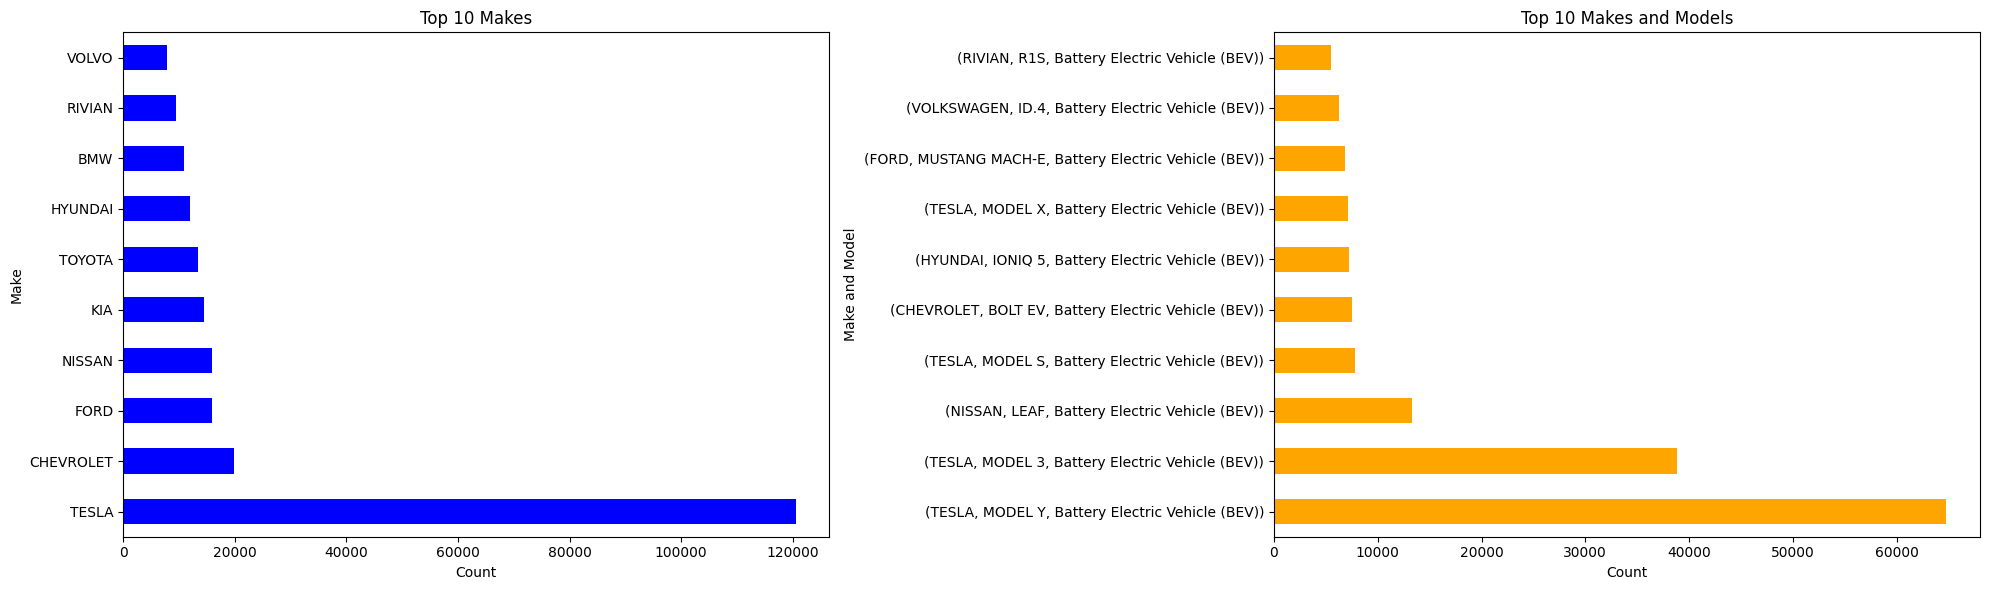

In [40]:
#B.) Creates a graph to visualize the result

#Creates a figure to plot bar chart data
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

#Top 15 Makes
make_count.head(10).plot(kind='barh', ax=axes[0], color='Blue') #Plots make data in a bar chart
axes[0].set_xlabel('Count') #Labels chart x axis
axes[0].set_ylabel('Make') #Labels chart y axis
axes[0].set_title('Top 10 Makes') #Labels chart title

#Top 15 Models
make_model_count.head(10).plot(kind='barh', ax=axes[1], color='Orange') #Plots make and model data in a bar chart
axes[1].set_xlabel('Count') #Labels chart x axis
axes[1].set_ylabel('Make and Model') #Labels chart y axis
axes[1].set_title('Top 10 Makes and Models') #Labels chart title

plt.tight_layout() #Adjusts spacing between subplots

plt.show()

C.) Graph Interpretation

The figure above shows the top 10 vehicle makes and models in Washington State. Overall, Tesla is the most popular make in the state, while Tesla, Chevrolet, and Ford models have the largest individual model counts.

Tesla and Ford have the largest number of vehicles registered in the state. Tesla has 120,514 registered vehicles, and Chevrolet has 19,927 vehicles. Ford and Kia are below them, with Ford at 14,516 and Nissan at 15,946 registered vehicles.

The "Top 10 Makes and Models" chart shows that battery electric vehicles make up the majority of the popular models in the dataset. Individually, the Tesla Model Y is the most popular Model in Washington, with the Tesla Model 3 and Nissan Leaf behind it.

To summarize, while Tesla is the most popular make in Washington State by a wide margin, the distribution of individual models is fairly evenly split outside of Teslas, with the majority being Battery Electric Vehicles.




Question B: How does electric range vary across car makes?

In [41]:
#A.) Creates a pivot table of average electric range by Make

#Removes vehicles with an electric range of 0
ev_electric_range_df = ev_df_no_outliers[ev_df_no_outliers['Electric Range'] > 0].copy()

#Creates a pivot table that summarizes the average electric range of makes in the dataset
pivot_table = ev_electric_range_df.pivot_table(index='Make', values='Electric Range', aggfunc=['mean', 'median', 'count']).sort_values(by=('mean', 'Electric Range'), ascending=False)

#Prints the top 5 highest average electric ranges
print(pivot_table.head(5))

                     mean         median          count
           Electric Range Electric Range Electric Range
Make                                                   
TESLA          241.475214          220.0          23945
JAGUAR         234.000000          234.0             90
POLESTAR       233.000000          233.0            199
CHEVROLET      152.631487          238.0           9750
VOLKSWAGEN     107.724832          125.0           1043


<Figure size 2000x600 with 0 Axes>

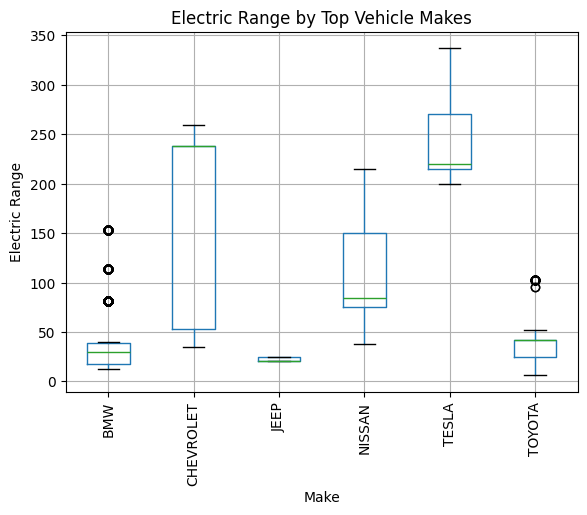

In [42]:
#B.) Creates a graph to visualize the result

#Get the 6 most common makes
top_makes = ev_electric_range_df['Make'].value_counts().head(6)
top_makes_df = ev_electric_range_df[ev_electric_range_df['Make'].isin(top_makes.index)]

#Create the chart
plt.figure(figsize=(20, 6))

#Creates boxplot
top_makes_df.boxplot(
    column='Electric Range',
    by='Make'
)

plt.xticks(rotation=90) #Rotates xticks
plt.xlabel('Make') #Labels x axis
plt.ylabel('Electric Range') #Labels y axis
plt.title('Electric Range by Top Vehicle Makes') #Labels chart title
plt.suptitle('')

plt.show()

C.) Graph Interpretation

The figure above shows the distribution of electric ranges for different vehicle makes in Washington State. Overall, Tesla and Chevrolet models have the highest average electric range compared with other common electric vehicles.

Tesla has the highest electric range values among the makes in the dataset. Their electric range values range from 200 miles to about 340 miles. Jaguar is the closest make to Tesla, with a mean electric range of 234 miles, compared to Tesla’s mean of 241.8 miles.

In comparison, other makes in the dataset have a lower span of electric range values. BMW, Jeep, and Toyota are examples of popular makes that average around 20 to 50 miles for their electric range. Chevrolet stands apart from other makes in the dataset as it has the widest electric range variability, from around 40 to 240 miles.

Overall, Tesla vehicles have the highest electric ranges on average; however, a vehicle’s electric range depends on its battery type, as battery electric vehicles will have a longer electric range.


Question C: What Battery Type is the most prevalent in Washington State?



In [43]:
#A.) Gathers the number of battery types in the data
battery_type_count = ev_df_no_outliers['Electric Vehicle Type'].value_counts()
print(battery_type_count,'\n')

battery_type_pct = ev_df_no_outliers['Electric Vehicle Type'].value_counts(normalize=True) * 100
print(battery_type_pct)

Electric Vehicle Type
Battery Electric Vehicle (BEV)            236994
Plug-in Hybrid Electric Vehicle (PHEV)     55162
Name: count, dtype: int64 

Electric Vehicle Type
Battery Electric Vehicle (BEV)            81.118991
Plug-in Hybrid Electric Vehicle (PHEV)    18.881009
Name: proportion, dtype: float64


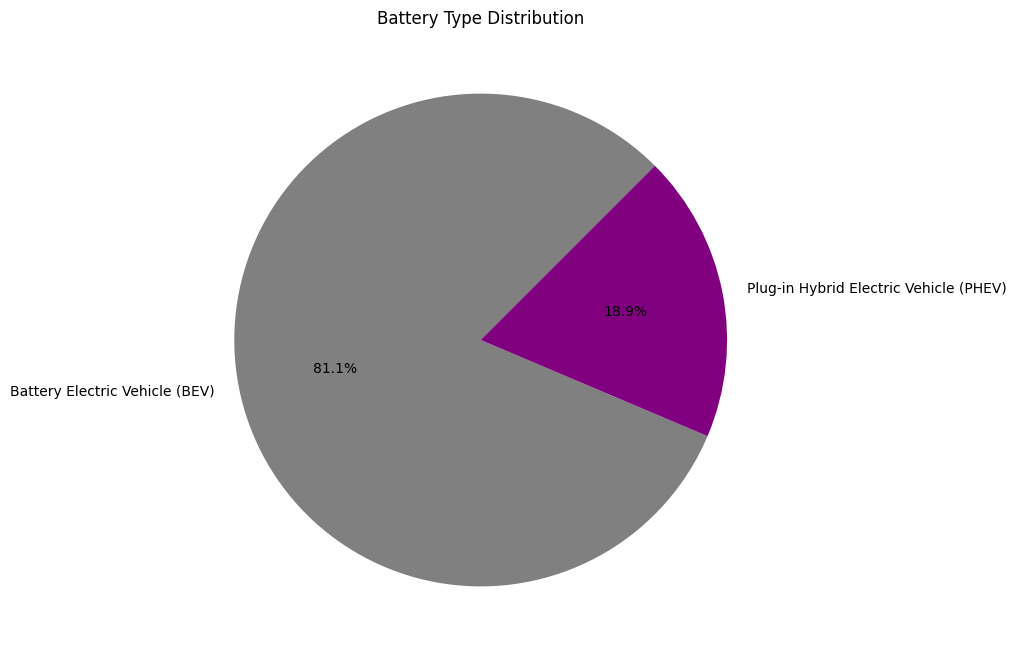

In [44]:
#B.) Creates a pie chart to determine which battery type makes up a greater percentage
plt.figure(figsize=(8, 8))
plt.pie(battery_type_count, labels=battery_type_count.index, autopct='%1.1f%%', startangle=45, colors=['Grey', 'Purple'])
plt.title('Battery Type Distribution')
plt.show()

C.) Graph Interpretation

The figure above shows the percentage distribution between battery electric vehicles (BEV) and plug-in hybrid electric vehicles (PHEV) in the state of Washington. Battery Electric Vehicles make up the majority of vehicles in the state rather than plug-in hybrid electric vehicles.

Battery electric vehicles clearly make up the majority of the overall electric vehicles in the state. Around eighty percent of electric vehicles in Washington State (81.1%) are Battery Electric Vehicles, whereas eighteen percent (18.9) are plug-in hybrid electric vehicles.

This trend matches the previous charts, as most popular models in the data are Battery Electric Vehicles, with notable exceptions such as the Toyota Prius Prime, Toyota Rav4 and Chevrolet Volt.

In short, entirely electric vehicles considerably outnumber hybrid electric cars and make up most of the market. Possible explanations for this trend could be the price of PHEVs, the wide availability of BEVs, and other market factors in the State of Washington.

Step 4 - Summary:

Main Inquiry Question:

What types of electric vehicles are the most popular in Washington State?

Following my research, I found that battery electric vehicles make up the majority of electric vehicles in Washington State rather than plug-in electric vehicles. Tesla vehicles are the most popular make of electric vehicles in Washington with over 120,000 vehicles registered in the state. The Tesla Model Y is also the most popular model of vehicles in the state with 64,799 vehicles registered through the Washington DOL. I also found that Tesla vehicle stand out with a higher electric range than other makes. However, through my research I found that a vehicle's electric range depends on it's battery type rather than make and model. I can futher explore the characteristics of battery electric vehicles and plug-in vehicles, such as their Clean Alternative Fuel Vehicle (CAFV) Eligibility and overall power, to improve my understanding of what kinds of vehicles are popular in Washington State.